# Projeto de Machine Learning — Análise Exploratória de Dados (EDA)

## Predição de AVC (Stroke Prediction)

**APS1 — EDA**

- **Integrantes:** Adrielle Gabriel Santana, Oscar Rodrigues de Sousa Filho
- **Curso:** Bacharelado em Ciência da Computação — 4º Semestre
- **Data de entrega:** 14/09/2026
- **Dataset:** [Stroke Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
- **Tarefa da APS2:** Classificação (prever a variável `stroke`)

### Referências

- FEDESORIANO. *Stroke Prediction Dataset*. Kaggle, 2021. Disponível em: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
- PEDREGOSA, F. et al. *Scikit-learn: Machine Learning in Python*. JMLR 12, 2011.
- MCKINNEY, W. *Data Structures for Statistical Computing in Python*. SciPy, 2010 (pandas).
- WASKOM, M. *seaborn: statistical data visualization*. JOSS, 2021.


## 1. Carregamento e inspeção inicial dos dados

### Descrição das features do dataset

| Coluna | Descrição | Tipo |
| --- | --- | --- |
| `id` | Identificador único do paciente (sem valor preditivo) | numérico (int) |
| `gender` | Sexo do paciente (`Male`, `Female`, `Other`) | categórico nominal |
| `age` | Idade do paciente em anos | numérico contínuo |
| `hypertension` | 0 = não tem hipertensão, 1 = tem hipertensão | numérico binário (categórico) |
| `heart_disease` | 0 = não tem doença cardíaca, 1 = tem doença cardíaca | numérico binário (categórico) |
| `ever_married` | Se o paciente já foi casado (`Yes`/`No`) | categórico binário |
| `work_type` | Tipo de trabalho (`Private`, `Self-employed`, `Govt_job`, `children`, `Never_worked`) | categórico nominal |
| `Residence_type` | Tipo de residência (`Urban`/`Rural`) | categórico binário |
| `avg_glucose_level` | Nível médio de glicose no sangue | numérico contínuo |
| `bmi` | Índice de massa corporal (IMC) | numérico contínuo (possui ausentes) |
| `smoking_status` | Status de fumante (`formerly smoked`, `never smoked`, `smokes`, `Unknown`) | categórico nominal |
| `stroke` | **Variável alvo**: 0 = não sofreu AVC, 1 = sofreu AVC | numérico binário (target) |


# Projeto de Machine Learning


In [1]:
import kagglehub
import pandas as pd
import os

# Baixa a versão mais recente (retorna o caminho da PASTA)
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Monta o caminho completo até o arquivo CSV
arquivo_csv = os.path.join(path, "healthcare-dataset-stroke-data.csv")

# Cria a variável 'dataset' com o conteúdo do CSV
dataset = pd.read_csv(arquivo_csv)

# Confere que carregou certo
print(dataset.head())

Path to dataset files: C:\Users\adrie\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0  

In [2]:
# Só as colunas numéricas (int e float)
colunas_numericas = dataset.select_dtypes(include=["number"])

# Só as colunas NÃO numéricas (texto/categóricas)
colunas_nao_numericas = dataset.select_dtypes(exclude=["number"])


In [3]:
print(dataset.isnull().sum())


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [4]:
print(colunas_numericas.head())

      id   age  hypertension  heart_disease  avg_glucose_level   bmi  stroke
0   9046  67.0             0              1             228.69  36.6       1
1  51676  61.0             0              0             202.21   NaN       1
2  31112  80.0             0              1             105.92  32.5       1
3  60182  49.0             0              0             171.23  34.4       1
4   1665  79.0             1              0             174.12  24.0       1


In [5]:
print(colunas_nao_numericas.head())

   gender ever_married      work_type Residence_type   smoking_status
0    Male          Yes        Private          Urban  formerly smoked
1  Female          Yes  Self-employed          Rural     never smoked
2    Male          Yes        Private          Rural     never smoked
3  Female          Yes        Private          Urban           smokes
4  Female          Yes  Self-employed          Rural     never smoked


In [6]:
# Mostra nome de cada coluna, quantos valores únicos tem, e exemplos de valores
for coluna in dataset.columns:
    print(f"Coluna: {coluna}")
    print(f"  Tipo: {dataset[coluna].dtype}")
    print(f"  Valores únicos: {dataset[coluna].nunique()}")
    print(f"  Exemplos: {dataset[coluna].unique()[:5]}")
    print()

Coluna: id
  Tipo: int64
  Valores únicos: 5110
  Exemplos: [ 9046 51676 31112 60182  1665]

Coluna: gender
  Tipo: object
  Valores únicos: 3
  Exemplos: ['Male' 'Female' 'Other']

Coluna: age
  Tipo: float64
  Valores únicos: 104
  Exemplos: [67. 61. 80. 49. 79.]

Coluna: hypertension
  Tipo: int64
  Valores únicos: 2
  Exemplos: [0 1]

Coluna: heart_disease
  Tipo: int64
  Valores únicos: 2
  Exemplos: [1 0]

Coluna: ever_married
  Tipo: object
  Valores únicos: 2
  Exemplos: ['Yes' 'No']

Coluna: work_type
  Tipo: object
  Valores únicos: 5
  Exemplos: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Coluna: Residence_type
  Tipo: object
  Valores únicos: 2
  Exemplos: ['Urban' 'Rural']

Coluna: avg_glucose_level
  Tipo: float64
  Valores únicos: 3979
  Exemplos: [228.69 202.21 105.92 171.23 174.12]

Coluna: bmi
  Tipo: float64
  Valores únicos: 418
  Exemplos: [36.6  nan 32.5 34.4 24. ]

Coluna: smoking_status
  Tipo: object
  Valores únicos: 4
  Exemplos: ['forme

In [7]:
# Conta valores ausentes (NaN) por coluna
print("Valores ausentes por coluna:")
print(dataset.isnull().sum())

# Mostra a porcentagem de ausentes por coluna (mais fácil de interpretar)
print("\nPorcentagem de ausentes por coluna:")
print((dataset.isnull().sum() / len(dataset) * 100).round(2))

Valores ausentes por coluna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Porcentagem de ausentes por coluna:
id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64


In [8]:
# .shape devolve uma tupla (número de linhas, número de colunas)
print("Formato do dataset:", dataset.shape)
print("Número de instâncias (linhas):", dataset.shape[0])
print("Número de features (colunas):", dataset.shape[1])

Formato do dataset: (5110, 12)
Número de instâncias (linhas): 5110
Número de features (colunas): 12


In [9]:
# Visão geral: tipo de cada coluna + contagem de não-nulos, tudo de uma vez
dataset.info()

# Separando explicitamente pelos tipos (usando o select_dtypes que já vimos)
colunas_numericas = dataset.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas = dataset.select_dtypes(exclude=["number"]).columns.tolist()


# Nas categóricas: ver todos os valores possíveis, procurando categorias estranhas
for coluna in colunas_categoricas:
    print(f"{coluna}: {dataset[coluna].unique()}")

# Nas numéricas: estatísticas (min, max, média) pra achar valores impossíveis
print(dataset.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
gender: ['Male' 'Female' 'Other']
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type: ['Ur

In [10]:
# Contagem absoluta de cada classe na variável alvo
print("Contagem por classe (stroke):")
print(dataset["stroke"].value_counts())

# Proporção percentual de cada classe
print("\nProporção por classe (%):")
print((dataset["stroke"].value_counts(normalize=True) * 100).round(2))

Contagem por classe (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64

Proporção por classe (%):
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


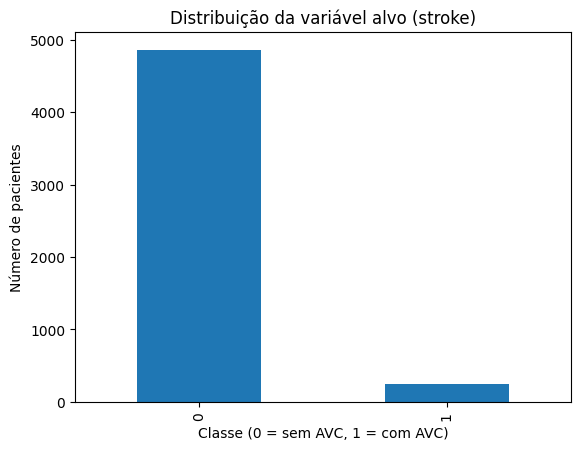

In [11]:
import matplotlib.pyplot as plt

dataset["stroke"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável alvo (stroke)")
plt.xlabel("Classe (0 = sem AVC, 1 = com AVC)")
plt.ylabel("Número de pacientes")
plt.show()

In [12]:
# Conta a incidência de 'Unknown' na coluna 'smoking_status'
unknown_smoking = dataset['smoking_status'].value_counts().get('Unknown', 0)
print(f"Número de 'Unknown' em smoking_status: {unknown_smoking}")

# Conta a incidência de 'Other' na coluna 'gender'
other_gender = dataset['gender'].value_counts().get('Other', 0)
print(f"Número de 'Other' em gender: {other_gender}")

Número de 'Unknown' em smoking_status: 1544
Número de 'Other' em gender: 1


### Verificando Valores Nulos (NaN) e `None`

Conforme já vimos, o método `.isnull().sum()` é a forma padrão de verificar a quantidade de valores `NaN` (Not a Number) em cada coluna de um DataFrame do pandas.

In [13]:
# Verificando valores NaN (Not a Number)
print('Contagem de valores NaN por coluna:')
display(dataset.isnull().sum())

Contagem de valores NaN por coluna:


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

É importante notar que, em DataFrames do pandas, valores `None` (do Python) em colunas numéricas são geralmente convertidos para `NaN` automaticamente. Em colunas de tipo `object` (que contêm strings ou objetos diversos), `None` pode permanecer como `None`. Podemos verificar explicitamente por `None` se necessário, embora seja menos comum após a leitura de dados típicos.

In [14]:
# Verificando explicitamente por valores None em colunas do tipo 'object'
# (Pandas geralmente converte None para NaN em colunas numéricas)

print('\nContagem de valores None por coluna (apenas para colunas \'object\'):')
none_counts = {}
for col in dataset.select_dtypes(include='object').columns:
    none_counts[col] = (dataset[col] == None).sum()
display(pd.Series(none_counts))


Contagem de valores None por coluna (apenas para colunas 'object'):


gender            0
ever_married      0
work_type         0
Residence_type    0
smoking_status    0
dtype: int64

### Verificando Valores Zero

Agora, vamos verificar a presença de valores zero em cada coluna, pois em alguns contextos, zero pode ser considerado um valor 'ausente' ou atípico, dependendo do significado da coluna.

In [15]:
# Contagem de valores zero por coluna
print('\nContagem de valores zero por coluna:')
zero_counts = {}
for col in dataset.columns:
    # Para evitar erros com colunas de texto, verificamos apenas onde o tipo é numérico
    if pd.api.types.is_numeric_dtype(dataset[col]):
        zero_counts[col] = (dataset[col] == 0).sum()
    else:
        zero_counts[col] = 'Não aplicável (coluna não numérica)'
display(pd.Series(zero_counts))


Contagem de valores zero por coluna:


id                                                     0
gender               Não aplicável (coluna não numérica)
age                                                    0
hypertension                                        4612
heart_disease                                       4834
ever_married         Não aplicável (coluna não numérica)
work_type            Não aplicável (coluna não numérica)
Residence_type       Não aplicável (coluna não numérica)
avg_glucose_level                                      0
bmi                                                    0
smoking_status       Não aplicável (coluna não numérica)
stroke                                              4861
dtype: object

In [16]:
# Filtrando o dataset para mostrar linhas onde 'bmi' é igual a zero
bmi_zero_df = dataset[dataset['bmi'] == 0]

print("Linhas onde 'bmi' é zero (primeiras 10):")
display(bmi_zero_df.head(10))

Linhas onde 'bmi' é zero (primeiras 10):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [17]:
# Filtrando o dataset para mostrar linhas onde 'bmi' é NaN (nulo)
bmi_nan_df = dataset[dataset['bmi'].isnull()]

print("Linhas onde 'bmi' é NaN (primeiras 10):")
display(bmi_nan_df.head(10))

Linhas onde 'bmi' é NaN (primeiras 10):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
29,69160,Male,59.0,0,0,Yes,Private,Rural,211.78,NaN,formerly smoked,1
43,1845,Female,63.0,0,0,Yes,Private,Urban,90.90,NaN,formerly smoked,1
46,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,NaN,Unknown,1
50,18587,Female,76.0,0,0,No,Private,Urban,89.96,NaN,Unknown,1
51,15102,Male,78.0,1,0,Yes,Private,Urban,75.32,NaN,formerly smoked,1


### Verificando Consistência dos Dados

Vamos agora verificar se há valores nas colunas numéricas que estão fora de um range considerado válido, indicando possíveis erros na coleta ou registro dos dados.

#### Consistência da Coluna `age`

Vamos verificar idades abaixo de 0 ou acima de 121 anos (um limite comum para a idade humana).

In [18]:
# Verificando 'age' fora da faixa (abaixo de 0 ou acima de 121)
inconsistent_age = dataset[(dataset['age'] < 0) | (dataset['age'] > 121)]

print("Linhas com 'age' inconsistente:")
if not inconsistent_age.empty:
    display(inconsistent_age)
else:
    print("Nenhuma idade inconsistente encontrada.")

Linhas com 'age' inconsistente:
Nenhuma idade inconsistente encontrada.


#### Consistência da Coluna `avg_glucose_level`

Para `avg_glucose_level`, consideraremos valores fora da faixa de 30 mg/dL (hipoglicemia severa) a 600 mg/dL (hiperglicemia severa) como potencialmente inconsistentes, embora limites clínicos específicos possam variar.

In [19]:
# Verificando 'avg_glucose_level' fora da faixa (ex: < 30 ou > 600)
inconsistent_glucose = dataset[(dataset['avg_glucose_level'] < 30) | (dataset['avg_glucose_level'] > 600)]

print("Linhas com 'avg_glucose_level' inconsistente:")
if not inconsistent_glucose.empty:
    display(inconsistent_glucose)
else:
    print("Nenhum nível de glicose inconsistente encontrado.")

Linhas com 'avg_glucose_level' inconsistente:
Nenhum nível de glicose inconsistente encontrado.


#### Consistência da Coluna `bmi`

Para `bmi`, vamos verificar valores abaixo de 10 (considerado subnutrição extrema) ou acima de 80 (obesidade mórbida extrema), que são raros na população geral.

In [20]:
# Verificando 'bmi' fora da faixa (ex: < 10 ou > 80)
inconsistent_bmi = dataset[(dataset['bmi'] < 10) | (dataset['bmi'] > 80)]

print("Linhas com 'bmi' inconsistente:")
if not inconsistent_bmi.empty:
    display(inconsistent_bmi)
else:
    print("Nenhum BMI inconsistente encontrado.")

Linhas com 'bmi' inconsistente:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0


### Contagem de Incidências para Colunas Categóricas

Vamos agora verificar a distribuição de cada categoria nas colunas não numéricas para identificar desbalanceamentos ou categorias com poucos exemplos.

In [21]:
print("Contagem de incidências por categoria nas colunas categóricas:\n")
for coluna in colunas_categoricas:
    print(f"Coluna: {coluna}")
    display(dataset[coluna].value_counts())
    print("\n" + "-" * 50 + "\n")

Contagem de incidências por categoria nas colunas categóricas:

Coluna: gender


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


--------------------------------------------------

Coluna: ever_married


ever_married
Yes    3353
No     1757
Name: count, dtype: int64


--------------------------------------------------

Coluna: work_type


...


--------------------------------------------------

Coluna: Residence_type


Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


--------------------------------------------------

Coluna: smoking_status


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


--------------------------------------------------



### Contagem de Zeros e Uns em Colunas Numéricas

Agora vamos verificar a contagem de 0s e 1s nas colunas numéricas que geralmente representam categorias binárias ou a variável alvo (`stroke`), para entender o balanceamento desses valores.

In [22]:
print("Contagem de Zeros e Uns por Coluna (numéricas binárias):\n")

# Filtra as colunas que são numéricas e que contêm apenas 0 e 1 (ou predominantemente)
# Excluímos 'id' e 'age' e 'avg_glucose_level' e 'bmi' pois são contínuas ou IDs
binary_numeric_columns = ['hypertension', 'heart_disease', 'stroke']

for coluna in binary_numeric_columns:
    print(f"Coluna: {coluna}")
    zero_count = (dataset[coluna] == 0).sum()
    one_count = (dataset[coluna] == 1).sum()

    print(f"  Contagem de 0: {zero_count}")
    print(f"  Contagem de 1: {one_count}")

    # Calcula a porcentagem
    total_count = zero_count + one_count
    if total_count > 0:
        zero_percent = (zero_count / total_count) * 100
        one_percent = (one_count / total_count) * 100
        print(f"  Porcentagem de 0: {zero_percent:.2f}%")
        print(f"  Porcentagem de 1: {one_percent:.2f}%")
    else:
        print("  (Não há valores 0 ou 1 nesta coluna)")
    print("\n" + "-" * 50 + "\n")


Contagem de Zeros e Uns por Coluna (numéricas binárias):



Coluna: hypertension
  Contagem de 0: 4612
  Contagem de 1: 498
  Porcentagem de 0: 90.25%
  Porcentagem de 1: 9.75%

--------------------------------------------------

Coluna: heart_disease
  Contagem de 0: 4834
  Contagem de 1: 276
  Porcentagem de 0: 94.60%
  Porcentagem de 1: 5.40%

--------------------------------------------------

Coluna: stroke
  Contagem de 0: 4861
  Contagem de 1: 249
  Porcentagem de 0: 95.13%
  Porcentagem de 1: 4.87%

--------------------------------------------------



In [23]:
# Seleciona só as colunas numéricas
numericas = dataset.select_dtypes(include="number")

# Monta uma tabela com as três estatísticas pedidas, uma coluna cada
estatisticas = pd.DataFrame({
    "média": numericas.mean(),
    "mediana": numericas.median(),
    "desvio_padrão": numericas.std()
})

print(estatisticas.round(2))

                      média   mediana  desvio_padrão
id                 36517.83  36932.00       21161.72
age                   43.23     45.00          22.61
hypertension           0.10      0.00           0.30
heart_disease          0.05      0.00           0.23
avg_glucose_level    106.15     91.88          45.28
bmi                   28.89     28.10           7.85
stroke                 0.05      0.00           0.22


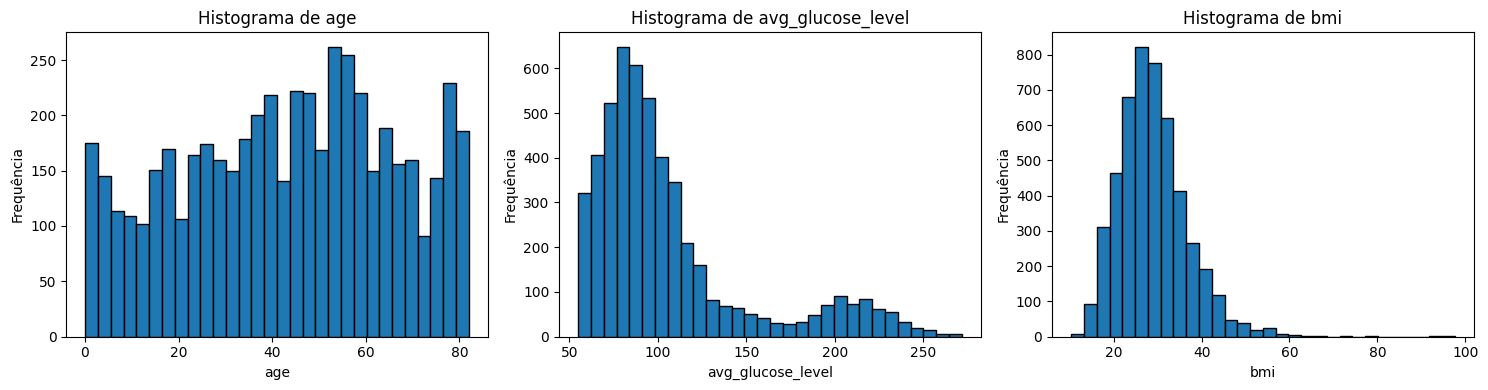

In [24]:
import matplotlib.pyplot as plt

variaveis_continuas = ["age", "avg_glucose_level", "bmi"]

# Cria uma figura com 3 gráficos lado a lado (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, coluna in enumerate(variaveis_continuas):
    axes[i].hist(dataset[coluna].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(f"Histograma de {coluna}")
    axes[i].set_xlabel(coluna)
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

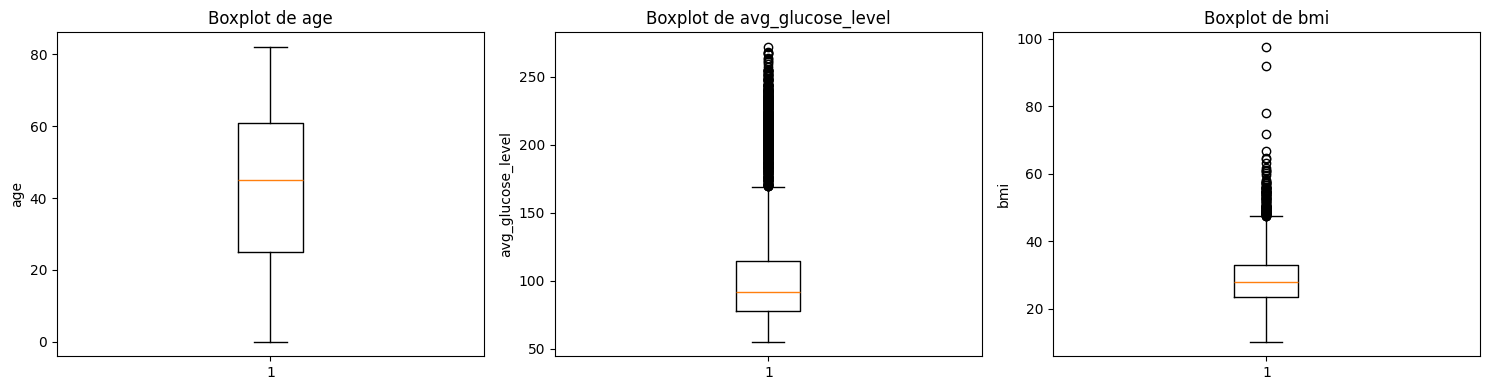

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, coluna in enumerate(variaveis_continuas):
    axes[i].boxplot(dataset[coluna].dropna())
    axes[i].set_title(f"Boxplot de {coluna}")
    axes[i].set_ylabel(coluna)

plt.tight_layout()
plt.show()

In [26]:
for coluna in colunas_categoricas:
    print(f"\n=== {coluna} ===")
    print("Contagem:")
    print(dataset[coluna].value_counts())
    print("\nPorcentagem (%):")
    print((dataset[coluna].value_counts(normalize=True) * 100).round(2))


=== gender ===
Contagem:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Porcentagem (%):
gender
Female    58.59
Male      41.39
Other      0.02
Name: proportion, dtype: float64

=== ever_married ===
Contagem:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Porcentagem (%):
ever_married
Yes    65.62
No     34.38
Name: proportion, dtype: float64

=== work_type ===
Contagem:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Porcentagem (%):
work_type
Private          57.24
Self-employed    16.03
children         13.44
Govt_job         12.86
Never_worked      0.43
Name: proportion, dtype: float64

=== Residence_type ===
Contagem:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Porcentagem (%):
Residence_type
Urban    50.8
Rural    49.2
Name: proportion, dtype: float64

=== smoking_status ===
Contagem:
smoking_status
never sm

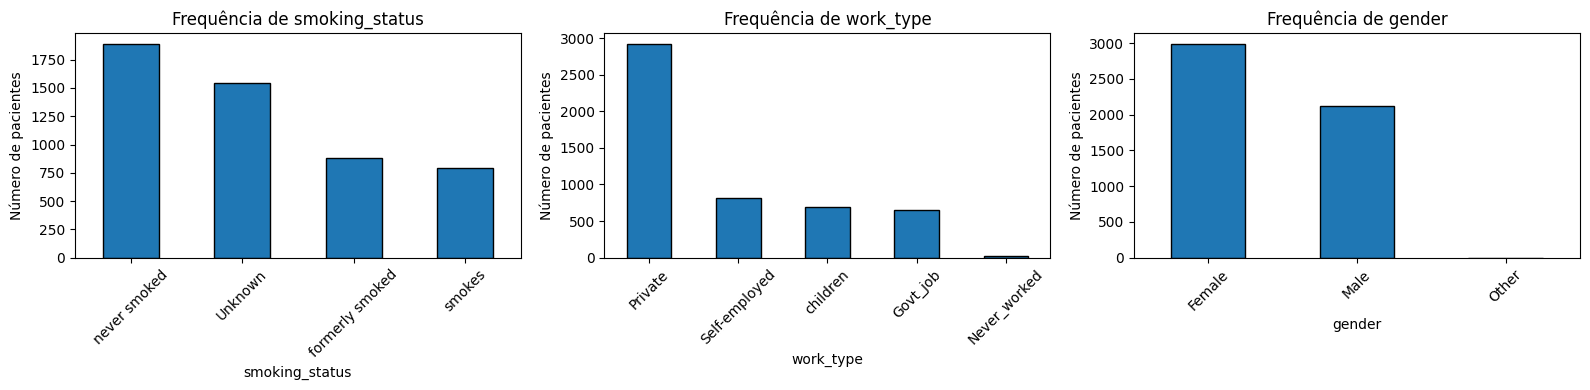

In [27]:
categoricas_grafico = ["smoking_status", "work_type", "gender"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, coluna in enumerate(categoricas_grafico):
    dataset[coluna].value_counts().plot(kind="bar", ax=axes[i], edgecolor="black")
    axes[i].set_title(f"Frequência de {coluna}")
    axes[i].set_xlabel(coluna)
    axes[i].set_ylabel("Número de pacientes")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Resolvendo `NameError`: Recarregando Dados

O erro `NameError` indica que o notebook pode ter sido executado fora de ordem ou o kernel foi reiniciado, fazendo com que as variáveis `dataset`, `colunas_numericas` e `colunas_categoricas` não estivessem definidas. Esta célula recarregará os dados e redefinirá essas variáveis essenciais para que as etapas subsequentes possam ser executadas.

In [28]:
import kagglehub
import pandas as pd
import os

# Recarrega o dataset para garantir que esteja definido
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
arquivo_csv = os.path.join(path, "healthcare-dataset-stroke-data.csv")
dataset = pd.read_csv(arquivo_csv)

# Redefine as listas de colunas numéricas e categóricas
colunas_numericas = dataset.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas = dataset.select_dtypes(exclude=["number"]).columns.tolist()

print("Dataset e listas de colunas recarregados com sucesso.")

Dataset e listas de colunas recarregados com sucesso.


In [29]:
from sklearn.model_selection import train_test_split

# Remove id (identificador, sem valor preditivo) e separa target
X = dataset.drop(columns=['id', 'stroke'])
y = dataset['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y            # mantém ~5% de AVC em treino e teste
)

print('Treino:', X_train.shape, '| % AVC:', round(y_train.mean()*100, 2))
print('Teste :', X_test.shape,  '| % AVC:', round(y_test.mean()*100, 2))

Treino: (4088, 10) | % AVC: 4.87
Teste : (1022, 10) | % AVC: 4.89


In [30]:
train = X_train.copy()
train['stroke'] = y_train.values

num_cols = train.select_dtypes(include='number').columns.drop('stroke').tolist()
cat_cols = train.select_dtypes(exclude='number').columns.tolist()

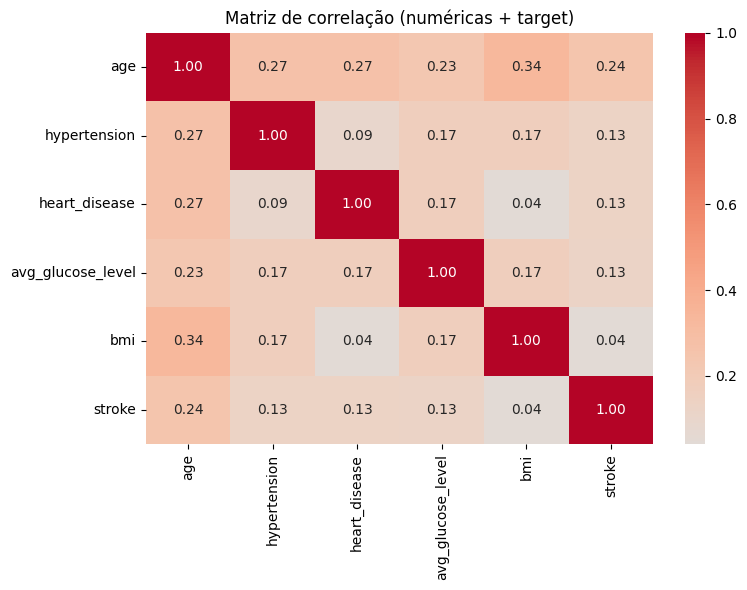

Correlação de cada numérica com stroke:
stroke               1.000
age                  0.243
hypertension         0.133
heart_disease        0.127
avg_glucose_level    0.125
bmi                  0.044
Name: stroke, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ['stroke']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação (numéricas + target)')
plt.tight_layout()
plt.show()

print('Correlação de cada numérica com stroke:')
print(train[num_cols + ['stroke']].corr()['stroke']
      .sort_values(ascending=False).round(3))

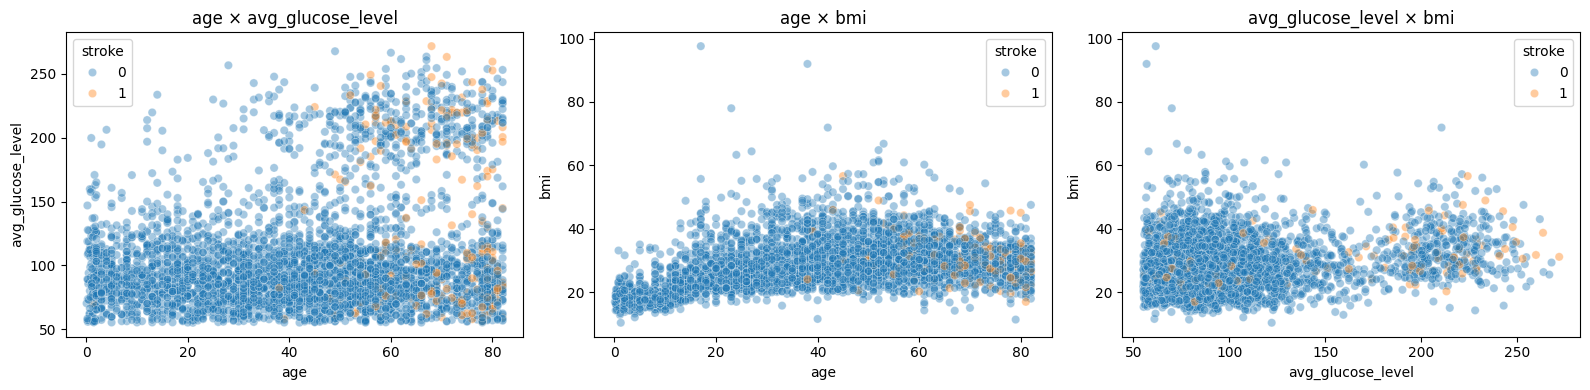

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=train, x='age', y='avg_glucose_level',
                hue='stroke', alpha=0.4, ax=axes[0])
sns.scatterplot(data=train, x='age', y='bmi',
                hue='stroke', alpha=0.4, ax=axes[1])
sns.scatterplot(data=train, x='avg_glucose_level', y='bmi',
                hue='stroke', alpha=0.4, ax=axes[2])
for ax in axes:
    ax.set_title(ax.get_xlabel() + ' × ' + ax.get_ylabel())
plt.tight_layout()
plt.show()

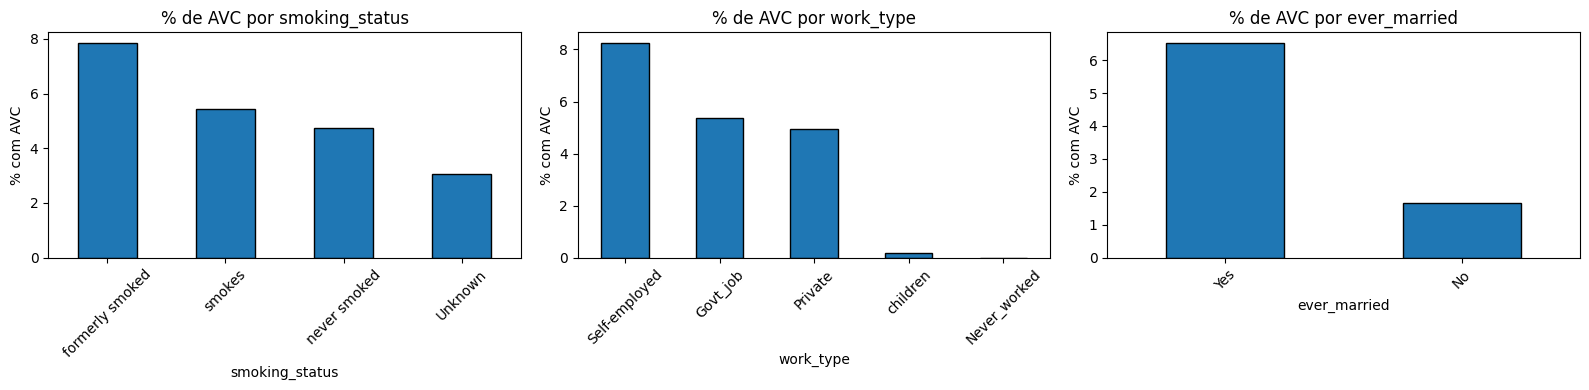

stroke,0,1
smoking_status,,
Unknown,0.970,0.030
formerly smoked,0.922,0.078
never smoked,0.953,0.047
smokes,0.946,0.054


In [33]:
cats_alvo = ['smoking_status', 'work_type', 'ever_married']  # escolha 3

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cats_alvo):
    taxa = (train.groupby(col)['stroke'].mean() * 100).sort_values(ascending=False)
    taxa.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'% de AVC por {col}')
    ax.set_ylabel('% com AVC')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Versão em tabela de contingência (proporção por linha)
pd.crosstab(train['smoking_status'], train['stroke'], normalize='index').round(3)

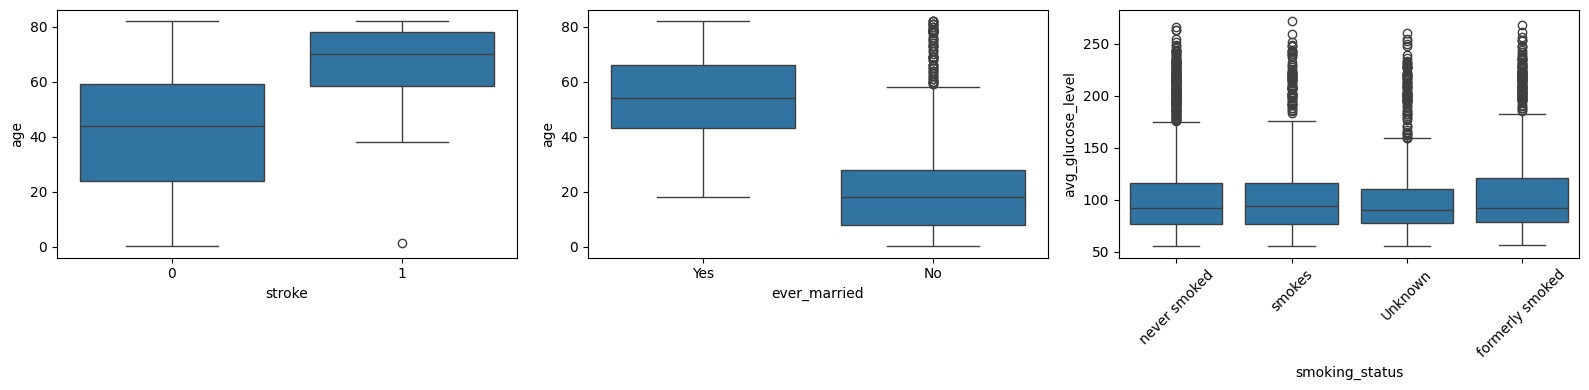

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=train, x='stroke', y='age', ax=axes[0])
sns.boxplot(data=train, x='ever_married', y='age', ax=axes[1])
sns.boxplot(data=train, x='smoking_status', y='avg_glucose_level', ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Pré-processamento para modelagem

Com base nos achados das seções 1–3, definimos abaixo as estratégias de pré-processamento e as justificativas para cada decisão.

### 4.1 Valores ausentes

- A única coluna com valores ausentes é **`bmi`** (~3,9% das linhas, ~201 de 5110).
- **Estratégia escolhida: imputação pela mediana.** A mediana foi preferida à média porque `bmi` apresenta cauda à direita (indivíduos com IMC muito alto), o que tornaria a média sensível a esses outliers. Remover as linhas foi descartado pois isso descartaria ~4% dos dados, incluindo casos de `stroke=1`, o que pioraria o já forte desbalanceamento da classe positiva.
- As demais colunas não possuem `NaN`, então nenhuma outra imputação é necessária.

### 4.2 Outliers

- Nas variáveis `avg_glucose_level` e `bmi` observamos outliers legítimos nos boxplots da seção 2 (pacientes com glicose/IMC muito elevados), que são clinicamente plausíveis e potencialmente **informativos para prever AVC** (hiperglicemia e obesidade são fatores de risco conhecidos).
- **Estratégia escolhida: manter os outliers, sem remoção ou winsorização**, e usar **padronização (StandardScaler)** em vez de normalização Min-Max, pois o StandardScaler é menos sensível a outliers isolados do que espremer tudo em um intervalo fixo [0,1]. Remover esses pontos poderia jogar fora justamente os casos de maior risco.
- Para `age`, o boxplot não indicou outliers relevantes (valores dentro do intervalo fisiológico esperado).

### 4.3 Encoding de variáveis categóricas

- Colunas nominais sem ordem natural: `gender`, `work_type`, `Residence_type`, `smoking_status`, `ever_married`.
- **Estratégia escolhida: One-Hot Encoding** para todas elas, pois nenhuma possui relação ordinal (ex.: não existe uma "ordem" entre `Private`, `Govt_job` e `Self-employed`). Usar Label Encoding introduziria uma relação de ordem/magnitude artificial que o modelo poderia interpretar erroneamente.
- `hypertension` e `heart_disease` já são binárias (0/1) e não precisam de encoding adicional.

### 4.4 Normalização / padronização

- **Estratégia escolhida: StandardScaler (padronização, média 0 e desvio padrão 1)** para as variáveis numéricas contínuas (`age`, `avg_glucose_level`, `bmi`).
- Justificativa: a padronização é a escolha recomendada quando pretendemos aplicar PCA (sensível à escala) e modelos baseados em distância/gradiente (ex.: regressão logística, SVM) na etapa de classificação (APS2). Min-Max Scaling foi descartado por ser mais sensível a outliers extremos, já discutidos acima.


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Colunas numéricas e categóricas (recalculadas a partir de X_train, sem 'id')
num_features = ['age', 'avg_glucose_level', 'bmi']
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                'work_type', 'Residence_type', 'smoking_status']

# Pipeline para numéricas: imputação pela mediana + padronização
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para categóricas: one-hot encoding
cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer combina os dois pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Ajusta no treino e transforma treino/teste (reutilizável na APS2)
X_train_prep = preprocessor.fit_transform(X_train[num_features + cat_features])
X_test_prep = preprocessor.transform(X_test[num_features + cat_features])

print('Shape treino pré-processado:', X_train_prep.shape)
print('Shape teste pré-processado :', X_test_prep.shape)


Shape treino pré-processado: (4088, 23)
Shape teste pré-processado : (1022, 23)


### 4.5 Redução de dimensionalidade (PCA)

Aplicamos PCA sobre os dados já pré-processados (imputados, padronizados e com one-hot encoding) para visualizar a estrutura dos dados em 2 dimensões e verificar se as classes (`stroke` = 0 ou 1) apresentam alguma separação visual.

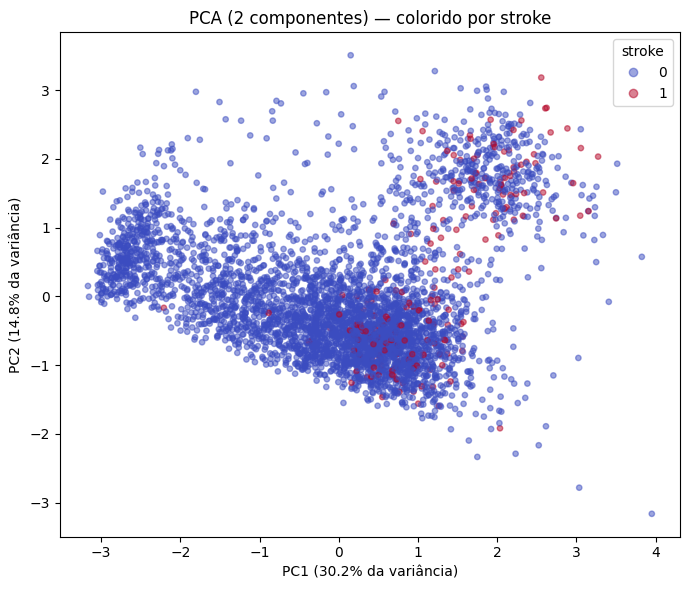

Variância explicada por componente: [0.302 0.148]
Variância explicada acumulada    : [0.302 0.45 ]


In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                       c=y_train, cmap='coolwarm', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.title('PCA (2 componentes) — colorido por stroke')
plt.legend(*scatter.legend_elements(), title='stroke')
plt.tight_layout()
plt.show()

print('Variância explicada por componente:', pca.explained_variance_ratio_.round(3))
print('Variância explicada acumulada    :', pca.explained_variance_ratio_.cumsum().round(3))


**Análise do resultado do PCA:** as duas primeiras componentes explicam apenas uma fração pequena da variância total (esperado, já que o one-hot encoding gera muitas colunas esparsas de baixa variância individual). No gráfico, os pontos de `stroke=1` (minoria) aparecem espalhados entre os de `stroke=0`, sem uma separação linear clara em 2D — o que já era esperado a partir das correlações fracas observadas na matriz de correlação (seção 3). Isso sugere que:

- O problema **não é linearmente separável** em poucas dimensões, reforçando a necessidade de modelos não-lineares (ex.: árvores, ensembles) na APS2.
- O forte desbalanceamento de classes (~5% de casos positivos) dificulta a visualização e deverá ser tratado explicitamente na etapa de modelagem (ex.: `class_weight='balanced'`, oversampling/SMOTE, ou ajuste de threshold).
- O pipeline de pré-processamento construído acima (`preprocessor`) está pronto para ser reaproveitado dentro de um `Pipeline` completo (pré-processamento + modelo) na APS2, garantindo que treino e teste sejam tratados de forma consistente e sem vazamento de dados (o `fit` ocorre apenas no treino).

## 5. Documentação e principais achados

### Resumo dos achados da EDA

1. **Estrutura dos dados:** 5110 instâncias e 12 colunas (11 features + `id` + target `stroke`), sendo 3 numéricas contínuas (`age`, `avg_glucose_level`, `bmi`), 5 categóricas nominais/binárias em texto, e 2 binárias já numéricas (`hypertension`, `heart_disease`).
2. **Qualidade dos dados:** único campo com ausentes é `bmi` (~4%). Não há duplicatas relevantes nem valores fora de faixa fisiológica em `age`, `avg_glucose_level` ou `bmi`. Há uma única linha com `gender = 'Other'`, categoria muito rara.
3. **Desbalanceamento severo do target:** apenas ~4,9% dos pacientes sofreram AVC (`stroke=1`), o que é o principal desafio para a etapa de classificação (APS2) — métricas como acurácia serão enganosas; deve-se priorizar recall/F1/AUC-ROC para a classe minoritária.
4. **Relações com o target:** `age` é a variável com maior correlação com `stroke`, seguida de `avg_glucose_level` e `heart_disease`/`hypertension`. Categoricamente, pacientes `ever_married='Yes'`, com `work_type` fora de `children`/`Never_worked`, e ex-fumantes (`formerly smoked`) apresentam taxas de AVC mais altas — coerente com o fato de essas categorias estarem associadas a faixas etárias mais avançadas.
5. **Separabilidade:** o PCA em 2D não mostrou separação linear clara entre as classes, indicando que modelos não-lineares tendem a performar melhor na APS2.

### Estratégias de pré-processamento propostas (resumo)

| Etapa | Estratégia | Justificativa |
| --- | --- | --- |
| Valores ausentes (`bmi`) | Imputação pela mediana | Robusta a outliers, preserva todas as linhas (inclusive casos positivos raros) |
| Outliers (`bmi`, `avg_glucose_level`) | Manter, sem remoção | Valores extremos são clinicamente relevantes como fatores de risco |
| Encoding categórico | One-Hot Encoding | Variáveis nominais sem ordem natural |
| Normalização | StandardScaler | Necessário para PCA e modelos sensíveis à escala; menos afetado por outliers que Min-Max |
| Dimensionalidade | PCA (visualização exploratória) | Investigar separabilidade das classes; não substitui as features originais na modelagem |
| Split treino/teste | 80/20 estratificado por `stroke` | Mantém a proporção da classe minoritária em ambos os conjuntos |

### Próximos passos (APS2)

- Tratar o desbalanceamento de classes (ex.: `class_weight='balanced'`, SMOTE, ajuste de threshold de decisão).
- Testar modelos não-lineares (Random Forest, Gradient Boosting) além de baseline linear (Regressão Logística).
- Reutilizar o `ColumnTransformer` (`preprocessor`) construído na seção 4 dentro de um `Pipeline` de modelagem completo.
- Avaliar com métricas adequadas ao desbalanceamento: recall, F1-score e AUC-ROC/PR-AUC, não apenas acurácia.
